In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
from scipy import stats

np.random.seed(42)
sns.set_style("whitegrid")

# Task 1

In [2]:
N = 100000
x = np.random.uniform(-1,1,N)
y = np.random.uniform(-1,1,N)
inside = x**2 + y**2 <= 1
pi_estimate = 4 * inside.mean()

print(f"Estimated π: {pi_estimate}")
print(f"True π: {math.pi}")

Estimated π: 3.14412
True π: 3.141592653589793


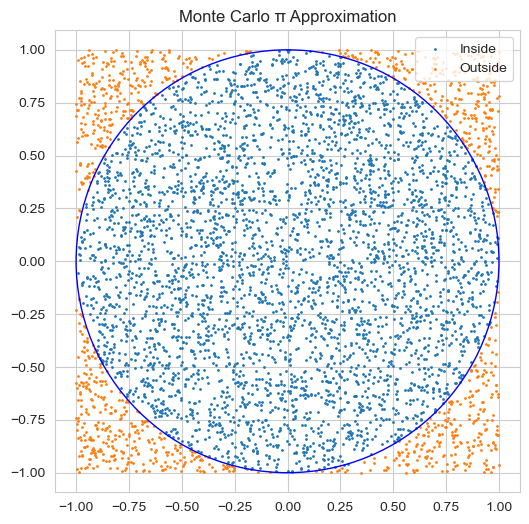

In [3]:
import matplotlib.pyplot as plt
x_small = x[:5000]
y_small = y[:5000]
inside_small = inside[:5000]

plt.figure(figsize=(6,6))
plt.scatter(x_small[inside_small], y_small[inside_small], s=1, label='Inside')
plt.scatter(x_small[~inside_small], y_small[~inside_small], s=1, label='Outside')
circle = plt.Circle((0,0), 1, color='blue', fill=False)
plt.gca().add_artist(circle)

plt.axis('equal')
plt.title("Monte Carlo π Approximation")
plt.legend()
plt.show()

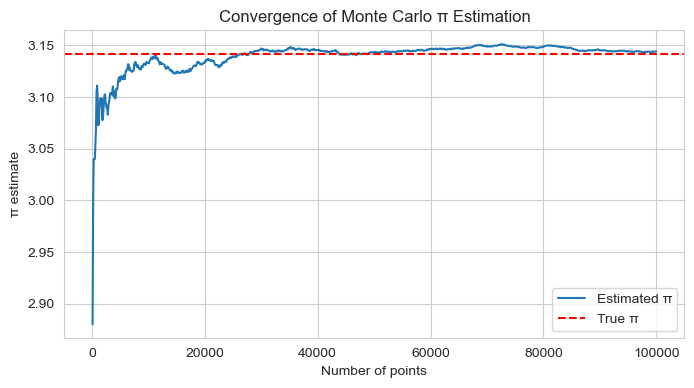

In [4]:
running_estimate = []
for i in range(100, N+1, 100):
    running_estimate.append(4 * inside[:i].mean())

plt.figure(figsize=(8,4))
plt.plot(range(100, N+1, 100), running_estimate, label='Estimated π')
plt.axhline(y=math.pi, color='red', linestyle='--', label='True π')
plt.xlabel("Number of points")
plt.ylabel("π estimate")
plt.title("Convergence of Monte Carlo π Estimation")
plt.legend()
plt.show()

In [5]:
threshold = 0.01
running_estimate_arr = np.array(running_estimate)
stable_n = np.where(np.abs(running_estimate_arr - np.pi) < threshold)[0]
if len(stable_n) > 0:
    print(f"{(stable_n[0]+1)*100}")

6400


At n = 6400 points, the running estimate first stabilizes within ±0.01 of true π.

# Task 2

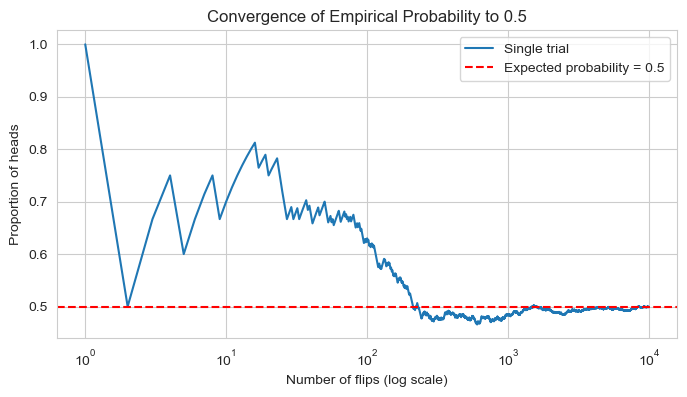

In [6]:
n = 10000
# repeats = 5
plt.figure(figsize=(8,4))
coin_flips = np.random.choice([0,1],n)
cumulative_heads = np.cumsum(coin_flips)
cumulative_count = np.arange(1, n+1)
running_proportion = cumulative_heads / cumulative_count

plt.plot(cumulative_count, running_proportion, label='Single trial')
plt.axhline(0.5, color='red', linestyle='--', label='Expected probability = 0.5')
plt.xscale('log')
plt.xlabel('Number of flips (log scale)')
plt.ylabel('Proportion of heads')
plt.title('Convergence of Empirical Probability to 0.5')
plt.legend()
plt.show()

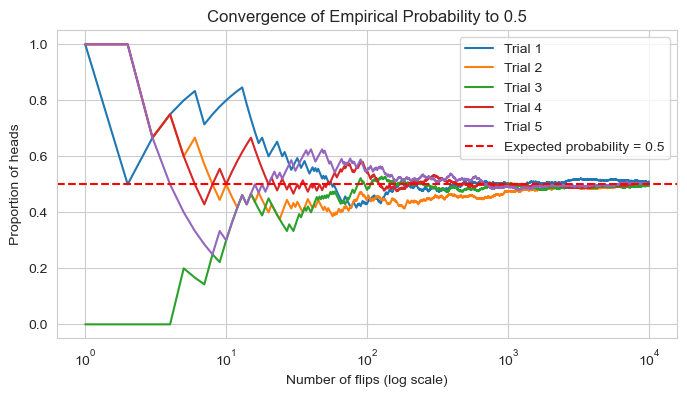

In [7]:
n = 10000
repeats = 5
plt.figure(figsize=(8,4))
for i in range(repeats):
    coin_flips = np.random.choice([0,1],n)
    cumulative_heads = np.cumsum(coin_flips)
    cumulative_count = np.arange(1, n+1)
    running_proportion = cumulative_heads / cumulative_count

    plt.plot(cumulative_count, running_proportion, label=f'Trial {i+1}')
plt.axhline(0.5, color='red', linestyle='--', label='Expected probability = 0.5')
plt.xscale('log')
plt.xlabel('Number of flips (log scale)')
plt.ylabel('Proportion of heads')
plt.title('Convergence of Empirical Probability to 0.5')
plt.legend()
plt.show()

Around 5000-6000 flips are needed for stable convergence.

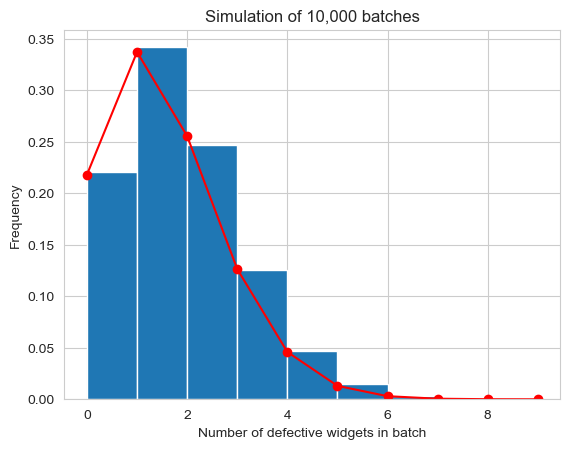

In [8]:
s = 10000
widgets = 50
rate = 0.03
conversions = stats.binom.rvs(n=widgets,p=rate,size=s)
plt.hist(conversions, bins=range(10), density=True)
x = np.arange(0, 10) # Defekt sayı 0-dan 9-a qədər olan nöqtələr
pmf_values = stats.binom.pmf(x, widgets, rate)
plt.plot(x, pmf_values, 'ro-', label='Binomial PMF')
plt.xlabel('Number of defective widgets in batch')
plt.ylabel('Frequency')
plt.title('Simulation of 10,000 batches')
plt.show()

In [9]:
p0_sim = np.mean(conversions == 0)
p0_theo = stats.binom.pmf(0, widgets, rate)

p3_plus_sim = np.mean(conversions >= 3)
p3_plus_theo = 1 - stats.binom.cdf(2, widgets, rate)
mean_sim = np.mean(conversions)
mean_theo = widgets * rate

print(f"P(0 defect): sim={p0_sim:.4f}, theo={p0_theo:.4f}")
print(f"P(3+ defect): sim={p3_plus_sim:.4f}, theo={p3_plus_theo:.4f}")
print(f"Expected value: sim={mean_sim:.2f}, theo={mean_theo:.2f}")

P(0 defect): sim=0.2202, theo=0.2181
P(3+ defect): sim=0.1916, theo=0.1892
Expected value: sim=1.50, theo=1.50


Simulation results are very close to theoretical values.
P(0 defect): sim=0.2024, theo=0.2181 — almost the same.
P(3+ defect): si m=091826, theo=0.1892 — small difference.
Expected value: sim=1.50, theo=1.50 — exact math.

1,000 batches is not enough. With 10,000 batches the results are more accurate.
More data means less error.